In [34]:
import pandas as pd
import os
import kagglehub
from dotenv import load_dotenv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Writing .env


In [5]:
#Load .env file for Kaggle Credentials
load_dotenv()
username = os.getenv("KAGGLE_USERNAME")
key = os.getenv("KAGGLE_KEY")

os.environ["KAGGLE_USERNAME"] = username
os.environ["KAGGLE_KEY"] = key

In [6]:
#Locate path to the Kaggle dataset
path = kagglehub.dataset_download(
    "aiaiaidavid/the-big-dataset-of-ultra-marathon-running"
)

100%|██████████| 246M/246M [00:02<00:00, 88.5MB/s]

Extracting files...


In [7]:
df = pd.read_csv(f"{path}/TWO_CENTURIES_OF_UM_RACES.csv", encoding="latin1")
df = df.drop(columns=["Event dates", "Event number of finishers", "Athlete club", "Athlete average speed"])

/tmp/ipykernel_3327/1301004287.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/TWO_CENTURIES_OF_UM_RACES.csv", encoding="latin1")


In [8]:
#1) Extract data since 2000s (TRY DIFFERENT THRESHOLDS)
df = df[df['Year of event'] >= 2000]

In [9]:
#2) Extract athletes that have data on a large portion of their career
threshold_of_races = 15
valid_athletes = df['Athlete ID'].value_counts()
valid_athletes = valid_athletes[valid_athletes > threshold_of_races].index
experienced_df = df[df['Athlete ID'].isin(valid_athletes)]
experienced_df['Athlete ID'].nunique()

81603

In [10]:
#Feature of race_count --> Number of times a unique ID appears
experienced_df = df[df['Athlete ID'].isin(valid_athletes)].copy()
experienced_df["race_count"] = experienced_df.groupby("Athlete ID").cumcount()

In [11]:
#Count the number of entries for each race
experienced_df['Event name'].value_counts()

,count
Event name,
Two Oceans Marathon (RSA),66695
Comrades Marathon - Down Run (RSA),49422
Comrades Marathon - Up Run (RSA),45381
Two Oceans Marathon - 50km Split (RSA),38182
Ultra Trail Tour du Mont Blanc (UTMB) (FRA),15324
...,...
Universiti Malaya 6 hours Ultra Marathon (MAS),1
Ranscombe Autumn Challenge 8 hours run - Sunday Run (GBR),1
Buckley's Chance 50K Trail Run (AUS),1


In [12]:
df_two_oceans = experienced_df[experienced_df['Event name'] == 'Two Oceans Marathon (RSA)'].copy()
df_two_oceans.dropna()
print(f"Total athletes: {df_two_oceans["Athlete ID"].nunique()}")
print(f"Total entries: {len(df_two_oceans["Athlete ID"])}")

Total athletes: 10447
Total entries: 66695


In [13]:
#Feature two_oceans_count --> Number of times they have ran this event
df_two_oceans["two_oceans_count"] = df_two_oceans.groupby("Athlete ID").cumcount()
df_two_oceans["two_oceans_count"]

,two_oceans_count
171456,0
171458,0
171462,0
171463,0
171465,0
...,...
6360620,5
6360630,15
6360638,12
6360639,13


In [14]:
#Calculate the athletes average speed in km/hr --> Used to Extract top threshold of fastest runners
#Since format H:MM:SS h harder to compare, numerically

df_two_oceans["distance_km"] = df_two_oceans["Event distance/length"].str.extract(r"(\d+\.?\d*)").astype(float)
df_two_oceans["distance_km"]
time_parts = df_two_oceans["Athlete performance"].str.replace(" h", "").str.split(":", expand=True)

df_two_oceans["hours"] = (
    time_parts[0].astype(float) +
    time_parts[1].astype(float) / 60 +
    time_parts[2].astype(float) / 3600
)

df_two_oceans["calculated_speed"] = df_two_oceans["distance_km"] / df_two_oceans["hours"]
df_two_oceans["calculated_speed"].head()

,calculated_speed
171456,17.571690
171458,17.486339
171462,17.241084
171463,17.058724
171465,16.959704


In [15]:
# runners are overwhelmingly from South Africa for this race
# potential domestic/foreign feature??
df_two_oceans["Athlete country"].value_counts()

,count
Athlete country,
RSA,63623
GBR,751
GER,444
ZIM,265
NAM,261
LES,174
USA,132
SWZ,101
AUS,95


In [16]:
df_two_oceans["finish_time_mins"] = df_two_oceans["hours"] * 60

In [17]:
#not doing the elite filter yet to see results

# 1. Athlete Age
df_two_oceans["athlete_age"] = df_two_oceans["Year of event"] - df_two_oceans["Athlete year of birth"]

# 2. Age squared - captures non-linear age effect (performance peaks then declines)
df_two_oceans["athlete_age_squared"] = df_two_oceans["athlete_age"] ** 2

# 3. Gender - binary encode
df_two_oceans["gender_male"] = (df_two_oceans["Athlete gender"] == "M").astype(int)

# 4. Domestic vs International
df_two_oceans["is_domestic"] = (df_two_oceans["Athlete country"] == "RSA").astype(int)

# 5. Experience - log transform to diminish returns of extra races
# log(1 + x) ensures athletes with 0 previous races don't cause log(0)
df_two_oceans["experience_log"] = np.log1p(df_two_oceans["race_count"])

# 6. Course Experience, have they run Two Oceans before?
df_two_oceans["course_exp"] = (df_two_oceans["two_oceans_count"] > 0).astype(int)

# 7. Age x Gender interaction
df_two_oceans["age_gender"] = df_two_oceans["athlete_age"] * df_two_oceans["gender_male"]

# 8. Age x log(experience) interaction
df_two_oceans["age_x_experience"] = df_two_oceans["athlete_age"] * df_two_oceans["experience_log"]

In [39]:
features = [
    "athlete_age",
    "athlete_age_squared",
    "gender_male",
    "is_domestic",
    "experience_log",
    "course_exp",
    "age_gender",
    "age_x_experience",
]

target = "finish_time_mins"

# 1. Correlation with TARGET
target_corr = df_two_oceans[features + ["finish_time_mins"]].corr()["finish_time_mins"].sort_values()
#print(target_corr)

# 2. Feature-to-feature correlation — multicollinearity check
feature_corr = df_two_oceans[features].corr()
#print(feature_corr)

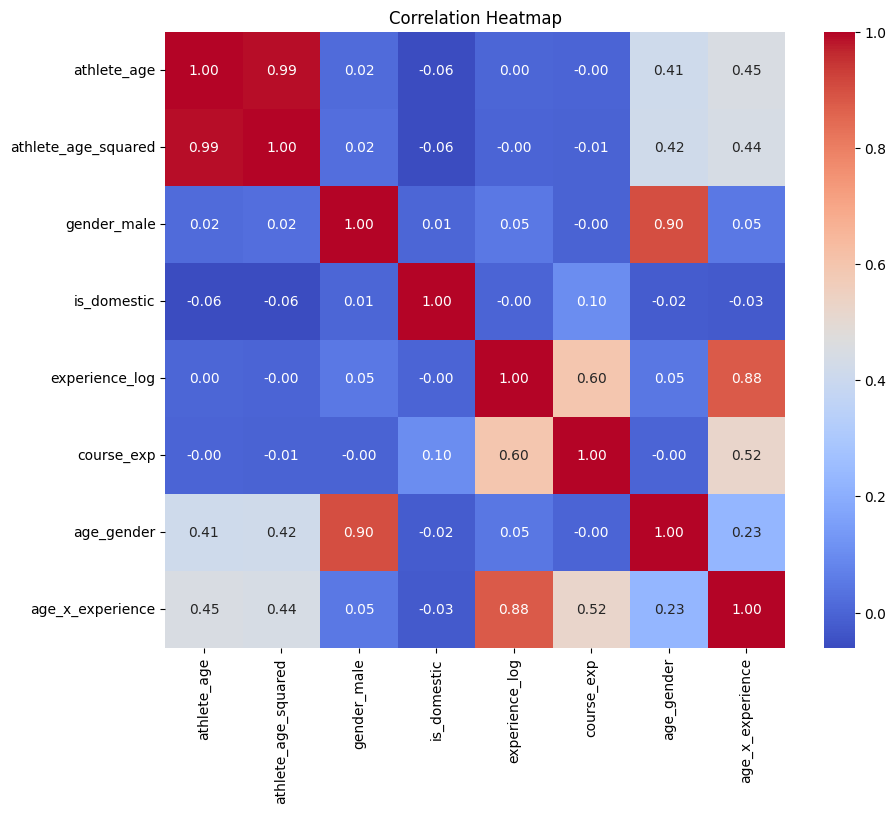

In [38]:
corr = df_two_oceans[features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [33]:
df_two_oceans["finish_time_mins"].describe()

,finish_time_mins
count,66695.000000
mean,339.118326
std,48.728944
min,185.666667
25%,305.716667
50%,344.016667
75%,377.200000
max,449.500000


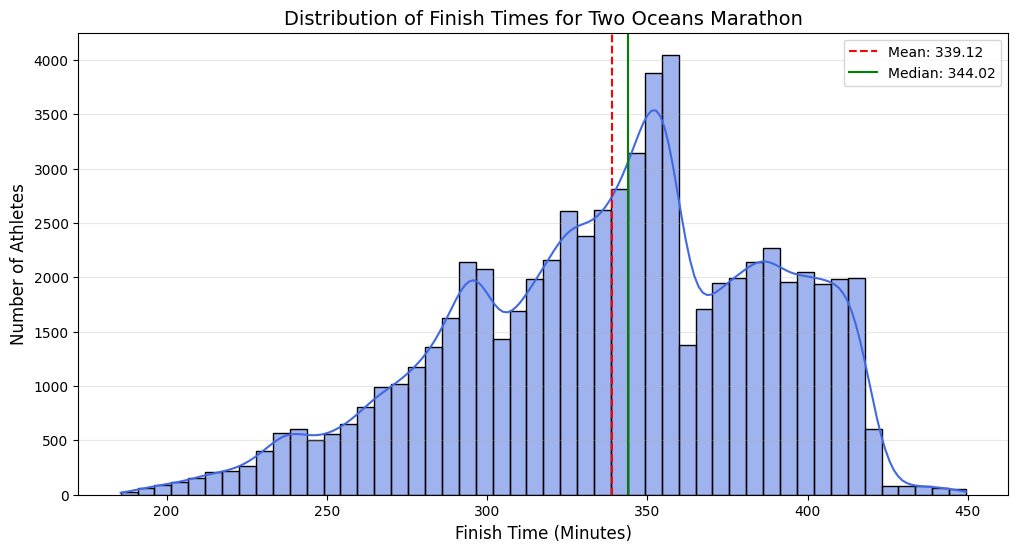

In [42]:
plt.figure(figsize=(12, 6))

# 2. Plot Histogram with a Kernel Density Estimate (KDE)
sns.histplot(df_two_oceans['finish_time_mins'], kde=True, bins=50, color='royalblue')

# 3. Add lines for Mean and Median to see the skewness
plt.axvline(df_two_oceans['finish_time_mins'].mean(), color='red', linestyle='--', label=f"Mean: {df_two_oceans['finish_time_mins'].mean():.2f}")
plt.axvline(df_two_oceans['finish_time_mins'].median(), color='green', linestyle='-', label=f"Median: {df_two_oceans['finish_time_mins'].median():.2f}")

# 4. Labels and Title
plt.title('Distribution of Finish Times for Two Oceans Marathon', fontsize=14)
plt.xlabel('Finish Time (Minutes)', fontsize=12)
plt.ylabel('Number of Athletes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Notes on the finish times distribution:

Left-skewed distribution, evidenced by mean lower than median

Concentrated between 340-360 minutes

This race has a hard cutoff of 7 hours, shown around 420 minutes

This hints that a log transform might help our models

In [19]:
#Filter the top 10% of the fastest athletes
# adding feature for 'elite' runners, top 10% threshold can be adjusted
# df_two_oceans['Elite'] = df_two_oceans['Calculated speed'] >= df_two_oceans['Calculated speed'].quantile(0.95)  # per race or per year
threshold = df_two_oceans["calculated_speed"].quantile(0.90)

df_top10 = df_two_oceans[df_two_oceans["calculated_speed"] >= threshold].copy()

df_top10["finish_time_mins"] = df_top10["hours"] * 60

print(f"Total Entries: {len(df_two_oceans)}")
print(f"Top 10% Entries: {len(df_top10)}\n")
print(df_top10["calculated_speed"].describe())


Total Entries: 66695
Top 10% Entries: 6670

count    6670.000000
mean       13.724108
std         1.175866
min        12.330275
25%        12.754045
50%        13.439104
75%        14.328104
max        18.096948
Name: calculated_speed, dtype: float64


In [20]:
# 1. Athlete Age
df_top10["athlete_age"] = df_top10["Year of event"] - df_top10["Athlete year of birth"]

# 2. Age squared - captures non-linear age effect (performance peaks then declines)
# center before squaring to reduce corr age x age^2
df_top10["athlete_age_squared"] = df_top10["athlete_age"] ** 2

# 3. Gender - binary encode
df_top10["gender_male"] = (df_top10["Athlete gender"] == "M").astype(int)

# 4. Domestic vs International
df_top10["is_domestic"] = (df_top10["Athlete country"] == "RSA").astype(int)

# fix the 5/6 redundancy somehow, maybe a ratio or drop one

# 5. Experience - log transform to diminish returns of extra races
# log(1 + x) ensures athletes with 0 previous races don't cause log(0)
df_top10["experience_log"] = np.log1p(df_top10["race_count"])

# 6. Course Experience, have they run Two Oceans before?
df_top10["course_exp"] = (df_top10["two_oceans_count"] > 0).astype(int)

# 7. Age x Gender interaction
df_top10["age_gender"] = df_top10["athlete_age"] * df_top10["gender_male"]

# 8. Age x log(experience) interaction
df_top10["age_x_experience"] = df_top10["athlete_age"] * df_top10["experience_log"]

In [59]:
features = [
    "athlete_age",
    "athlete_age_squared",
    "gender_male",
    "is_domestic",
    "experience_log",
    "course_exp",
    "age_gender",
    "age_x_experience",
]
target = "finish_time_mins"

# 1. Correlation with TARGET
target_corr = df_two_oceans[features + ["finish_time_mins"]].corr()["finish_time_mins"].sort_values()
print(target_corr)

# 2. Feature-to-feature correlation — multicollinearity check
feature_corr = df_two_oceans[features].corr()
print(feature_corr)

gender_male           -0.175396
experience_log        -0.053434
age_gender            -0.030975
course_exp            -0.021888
is_domestic            0.043140
age_x_experience       0.086417
athlete_age            0.304947
athlete_age_squared    0.306079
finish_time_mins       1.000000
Name: finish_time_mins, dtype: float64
                     athlete_age  athlete_age_squared  gender_male  \
athlete_age             1.000000             0.991608     0.015521   
athlete_age_squared     0.991608             1.000000     0.024182   
gender_male             0.015521             0.024182     1.000000   
is_domestic            -0.056922            -0.060739     0.005240   
experience_log          0.003153            -0.000672     0.049778   
course_exp             -0.001955            -0.006697    -0.003098   
age_gender              0.411705             0.417462     0.901516   
age_x_experience        0.451356             0.443743     0.049224   

                     is_domestic  experien

In [22]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [60]:
model_df = df_two_oceans[features + [target, "Year of event"]].dropna()

In [61]:
#TIME BASED MODEL SPLIT
train_df = model_df[model_df["Year of event"] <= 2015]
val_df   = model_df[(model_df["Year of event"] >= 2016) & (model_df["Year of event"] <= 2017)]
test_df  = model_df[model_df["Year of event"] >= 2018]

In [62]:
X_train, X_val, X_test = train_df[features], val_df[features], test_df[features]

# not scaled times
y_train_orig = train_df["finish_time_mins"]
y_val_orig   = val_df["finish_time_mins"]
y_test_orig  = test_df["finish_time_mins"]

y_train = np.log1p(train_df["finish_time_mins"])
y_val   = np.log1p(val_df["finish_time_mins"])
y_test  = np.log1p(test_df["finish_time_mins"])

In [63]:
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 52015 | Val: 7662 | Test: 7013


In [64]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)         # transform only
X_test_s  = scaler.transform(X_test)        # transform only

In [65]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  MAE:  {mae:.2f} mins")
    print(f"  RMSE: {rmse:.2f} mins")
    print(f"  R²:   {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1 — LINEAR REGRESSION (Ridge for stability)
# ══════════════════════════════════════════════════════════════════════════════
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

# Tune alpha on validation set
best_alpha, best_val_mae = 1.0, float("inf")
for alpha in [0.01, 0.1, 1, 10, 100]:
    m = Ridge(alpha=alpha).fit(X_train_s, y_train)
    val_preds_mins = np.expm1(m.predict(X_val_s))
    mae = mean_absolute_error(y_val_orig, val_preds_mins)
    if mae < best_val_mae:
        best_val_mae, best_alpha = mae, alpha

ridge_final = Ridge(alpha=best_alpha).fit(X_train_s, y_train)
test_preds_mins = np.expm1(ridge_final.predict(X_test_s))
results.append(evaluate("Ridge Regression", y_test_orig, test_preds_mins))

# Coefficients — interpretability
coef_df = pd.DataFrame({"feature": features, "coef": ridge_final.coef_})
print(coef_df.sort_values("coef", key=abs, ascending=False))


────────────────────────────────────────
  Ridge Regression
  MAE:  40.99 mins
  RMSE: 49.33 mins
  R²:   0.0729
               feature      coef
2          gender_male -0.053888
6           age_gender  0.029157
1  athlete_age_squared  0.028076
3          is_domestic  0.010014
7     age_x_experience  0.005348
4       experience_log -0.003432
5           course_exp  0.000863
0          athlete_age -0.000085


In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2 — REGRESSION TREE
# ══════════════════════════════════════════════════════════════════════════════
# Tune max_depth via validation MAE
best_depth, best_val_mae = 3, float("inf")
for depth in range(2, 12):
    m = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val))
    if mae < best_val_mae:
        best_val_mae, best_depth = mae, depth

tree_final = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
tree_final.fit(X_train, y_train)   # Trees don't need scaling
results.append(evaluate(f"Regression Tree (depth={best_depth})", y_test, tree_final.predict(X_test)))

# Feature importances
imp_df = pd.DataFrame({"feature": features, "importance": tree_final.feature_importances_})
print(imp_df.sort_values("importance", ascending=False))


────────────────────────────────────────
  Regression Tree (depth=2)
  MAE:  0.12 mins
  RMSE: 0.15 mins
  R²:   0.0758
               feature  importance
0          athlete_age    0.700657
6           age_gender    0.299343
2          gender_male    0.000000
1  athlete_age_squared    0.000000
3          is_domestic    0.000000
4       experience_log    0.000000
5           course_exp    0.000000
7     age_x_experience    0.000000


In [73]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 3 — GRADIENT BOOSTING (sklearn GBM)
# ══════════════════════════════════════════════════════════════════════════════
# searching for best parameters
param_dist = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.6, 0.7, 0.8],
    "min_samples_split": [5, 7, 10]
}
# best params were:

gbm = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    gbm,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print(f"Best Parameters: {random_search.best_params_}")
gbm_optimized = random_search.best_estimator_
gb_final_preds = np.expm1(gbm_optimized.predict(X_test))

results.append(evaluate("Gradient Boosting (optimized)", y_test, gb_final_preds))

Best Parameters: {'subsample': 0.6, 'n_estimators': 400, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.01}

────────────────────────────────────────
  Gradient Boosting (optimized)
  MAE:  330.50 mins
  RMSE: 330.83 mins
  R²:   -4658695.4055


This data fails to provide insights on how athletes trained for this marathon, travel fatigue, weather, and other factors that play a large role in athlete performance